# Netflix: Movies and TV Shows

In [1]:
#Librerías a usar:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [64]:
#Carga de datos
df_netflix = pd.read_csv('C:/Users/SERGIO/Desktop/Analisis Datos/Datos/Netflix.csv')

In [66]:
#Primera visualización
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [67]:
#Información general
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Contenido predominante en la plataforma

In [68]:
#Películas vs Series
conteo_peliculas_series = df_netflix['type'].value_counts().to_frame().reset_index()
conteo_peliculas_series

,type,count
0,Movie,6131
1,TV Show,2676


In [69]:
#Traduciendo
conteo_peliculas_series['type'] = conteo_peliculas_series['type'].replace({
    'Movie':'Película',
    'TV Show': 'Serie de TV'
})
conteo_peliculas_series

,type,count
0,Película,6131
1,Serie de TV,2676


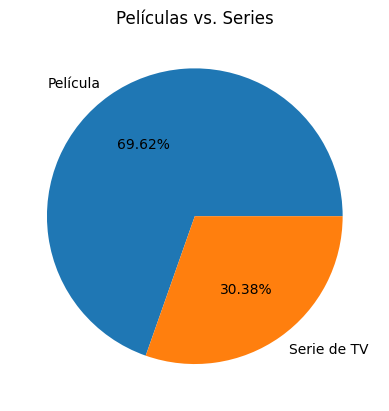

In [70]:
#Gráfico de pastel
plt.pie(
    conteo_peliculas_series['count'],
    labels = conteo_peliculas_series['type'],
    autopct='%1.2f%%'
)

plt.title('Películas vs. Series')
plt.show()

In [71]:
#Clasificaciones
df_netflix['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [72]:
#¿Existen valores Nulos?
df_netflix['rating'].isna().value_counts()

rating
False    8803
True        4
Name: count, dtype: int64

In [73]:
#Obteniendo nulos
df_netflix[df_netflix['rating'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [74]:
#Rellenando valores nulos
ratings_correctos = {
    'Gargantia on the Verdurous Planet': 'TV-14',
    'Little Lunch': 'TV-Y7',
    'My Honor Was Loyalty': 'TV-MA',
    '13TH: A Conversation with Oprah Winfrey & Ava DuVernay': 'TV-PG',
}

#Rellenando NaN
df_netflix['rating'] = df_netflix['rating'].fillna(df_netflix['title'].map(ratings_correctos))

#Comprobando
df_netflix[df_netflix['title'].isin([
    'Gargantia on the Verdurous Planet',
    'Little Lunch',
    'My Honor Was Loyalty',
    '13TH: A Conversation with Oprah Winfrey & Ava DuVernay',
])]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,TV-PG,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,TV-14,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,TV-Y7,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,TV-MA,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [75]:
#Obteniendo clasificaciones erroneas
df_netflix[df_netflix['rating'].isin(['74 min','84 min','66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [76]:
#Cambiando ratings incorrectos
df_netflix.loc[(df_netflix['title'].isin([
    'Louis C.K. 2017',
    'Louis C.K.: Hilarious',
    'Louis C.K.: Live at the Comedy Store'
])), 'rating'] = 'TV-MA'

#Comprobando
df_netflix[df_netflix['title'].isin([
    'Louis C.K. 2017',
    'Louis C.K.: Hilarious',
    'Louis C.K.: Live at the Comedy Store'
])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,TV-MA,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,TV-MA,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,TV-MA,NaN,Movies,The comic puts his trademark hilarious/thought...


In [77]:
#Películas UR
df_netflix[df_netflix['rating'] == 'UR']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7058,s7059,Movie,Immoral Tales,Walerian Borowczyk,"Lise Danvers, Fabrice Luchini, Charlotte Alexa...",France,"June 6, 2019",1974,UR,103 min,"Dramas, International Movies, Romantic Movies",This anthology illustrates the timeless nature...
7988,s7989,Movie,Sex Doll,Sylvie Verheyde,"Hafsia Herzi, Ash Stymest, Karole Rocher, Paul...","United Kingdom, France","July 10, 2017",2016,UR,103 min,"Dramas, International Movies, Romantic Movies",A high-end call girl falls for a handsome man ...
8790,s8791,Movie,You Don't Mess with the Zohan,Dennis Dugan,"Adam Sandler, John Turturro, Emmanuelle Chriqu...",United States,"September 1, 2019",2008,UR,113 min,"Action & Adventure, Comedies",An Israeli counterterrorism soldier with a sec...


In [78]:
#Cambiando ratings incorrectos
df_netflix.loc[(df_netflix['title'].isin([
    'Immoral Tales',
    'Sex Doll',
    "You Don't Mess with the Zohan"
])), 'rating'] = 'TV-MA'

#Comprobando
df_netflix[df_netflix['title'].isin([
    'Immoral Tales',
    'Sex Doll',
    "You Don't Mess with the Zohan"
])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7058,s7059,Movie,Immoral Tales,Walerian Borowczyk,"Lise Danvers, Fabrice Luchini, Charlotte Alexa...",France,"June 6, 2019",1974,TV-MA,103 min,"Dramas, International Movies, Romantic Movies",This anthology illustrates the timeless nature...
7988,s7989,Movie,Sex Doll,Sylvie Verheyde,"Hafsia Herzi, Ash Stymest, Karole Rocher, Paul...","United Kingdom, France","July 10, 2017",2016,TV-MA,103 min,"Dramas, International Movies, Romantic Movies",A high-end call girl falls for a handsome man ...
8790,s8791,Movie,You Don't Mess with the Zohan,Dennis Dugan,"Adam Sandler, John Turturro, Emmanuelle Chriqu...",United States,"September 1, 2019",2008,TV-MA,113 min,"Action & Adventure, Comedies",An Israeli counterterrorism soldier with a sec...


In [79]:
#Reconteo de los valores
df_netflix['rating'].value_counts()

rating
TV-MA       3214
TV-14       2161
TV-PG        864
R            799
PG-13        490
TV-Y7        335
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
Name: count, dtype: int64

In [80]:
#Creando función para asignar la categoría del rating
def categorizar(rating):
    if rating in ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'G']:
        return 'Infantil'
    elif rating in ['TV-PG', 'PG']:
        return 'Familiar'
    elif rating in ['TV-14', 'PG-13']:
        return 'Adolescentes'
    elif rating in ['TV-MA', 'R', 'NC-17']:
        return 'Adultos'
    else:
        return 'Sin Clasificación'

#Nueva columna
df_netflix['Category'] = df_netflix['rating'].apply(categorizar)

df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Adolescentes
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Adultos
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Adultos
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Adultos
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Adultos


In [81]:
#Conteo de categorías
print(f'{df_netflix['Category'].value_counts().sort_values(ascending=False)}\n')

#Porcentaje de cada categoría
porcentaje_categorias = df_netflix['Category'].value_counts(normalize=True).mul(100).round(1)
print(porcentaje_categorias)

Category
Adultos              4016
Adolescentes         2651
Familiar             1151
Infantil              909
Sin Clasificación      80
Name: count, dtype: int64

Category
Adultos              45.6
Adolescentes         30.1
Familiar             13.1
Infantil             10.3
Sin Clasificación     0.9
Name: proportion, dtype: float64


Text(0, 0.5, 'Cantidad de producciones')

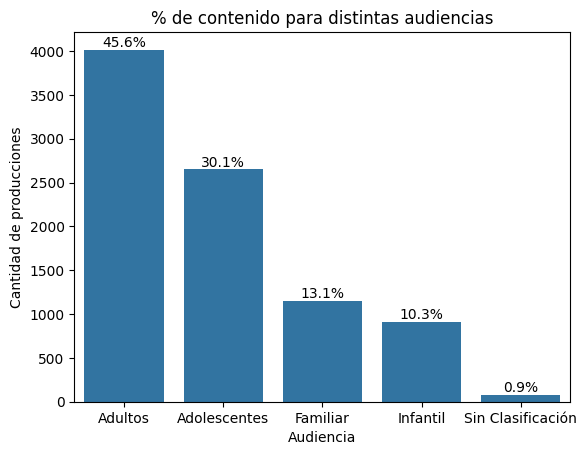

In [82]:
#Gráfico de barras
graf_categorias = sns.countplot(
    data = df_netflix,
    x = 'Category',
    order = df_netflix['Category'].value_counts().index
)

#Agregando etiquetas a las barras
total = len(df_netflix)

for p in graf_categorias.patches:
    porcentaje = 100 * p.get_height() / total

    graf_categorias.annotate(
        f'{porcentaje:.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('% de contenido para distintas audiencias')
plt.xlabel('Audiencia')
plt.ylabel('Cantidad de producciones')

In [83]:
#Conteo del tipo de producciones por categoría
df_netflix['Category'].groupby(df_netflix['type']).value_counts()

type     Category         
Movie    Adultos              2869
         Adolescentes         1917
         Familiar              828
         Infantil              442
         Sin Clasificación      75
TV Show  Adultos              1147
         Adolescentes          734
         Infantil              467
         Familiar              323
         Sin Clasificación       5
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de producciones')

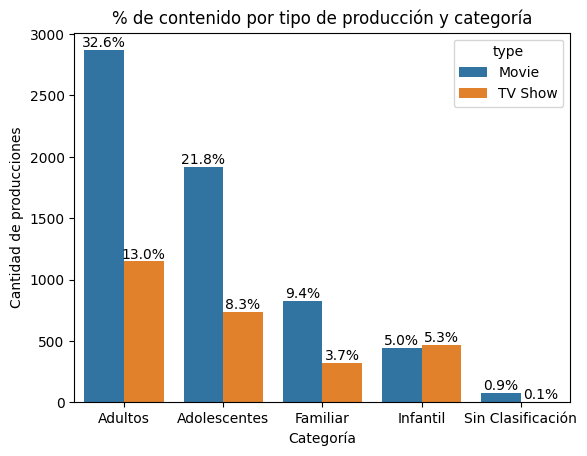

In [84]:
#Gráfico de barras por categoría y tipo
graf_categorias_tipo = sns.countplot(
    data = df_netflix,
    x = 'Category',
    hue = 'type',
    order = df_netflix['Category'].value_counts().index
)

#Agregando etiquetas a las barras
total = len(df_netflix)

for p in graf_categorias_tipo.patches:
    porcentaje = 100 * p.get_height() / total

    if p.get_height() > 0:
        graf_categorias_tipo.annotate(
            f'{porcentaje:.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom'
        )

plt.title('% de contenido por tipo de producción y categoría')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de producciones')

## Evolución del catálogo a través del tiempo

In [85]:
#Limpiando espacios en las fechas
df_netflix['date_added'] = df_netflix['date_added'].str.strip()

In [86]:
#Convirtiendo la variable date_added a tipo date
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'])
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  Category      8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(11)
memory usage: 894.6+ KB


In [87]:
#Creando columna para el año en que se agreg+o a la plataforma
df_netflix['year_added'] = df_netflix['date_added'].dt.year
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Category,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Adolescentes,2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Adultos,2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Adultos,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Adultos,2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Adultos,2021.0


In [88]:
#Cantidad de producciones agregadas por año
cantidad_agregados = df_netflix['year_added'].value_counts().sort_index()
cantidad_agregados

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad')

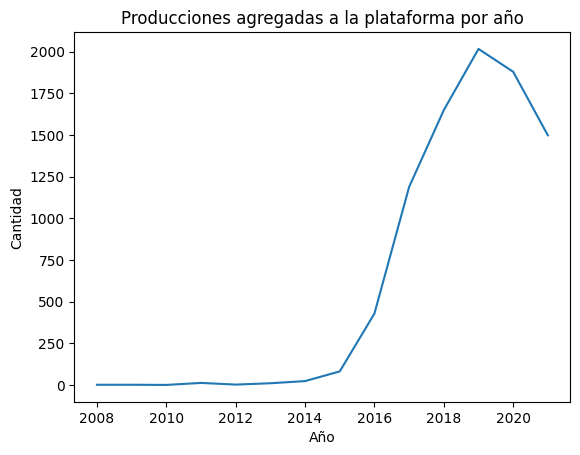

In [89]:
#Gráfico de líneas
cantidad_agregados.plot(
    kind = 'line'
)

plt.title('Producciones agregadas a la plataforma por año')
plt.xlabel('Año')
plt.ylabel('Cantidad')

In [90]:
#Agrupando por tipo de producción
agregados_tipo = df_netflix['year_added'].groupby([df_netflix['type']]).value_counts().to_frame()
agregados_tipo

count
type    year_added       
Movie   2019.0       1424
        2020.0       1284
        2018.0       1237
        2021.0        993
        2017.0        839
        2016.0        253
        2015.0         56
        2014.0         19
        2011.0         13
        2013.0          6
        2012.0          3
        2009.0          2
        2008.0          1
        2010.0          1
TV Show 2020.0        595
        2019.0        592
        2021.0        505
        2018.0        412
        2017.0        349
        2016.0        176
        2015.0         26
        2013.0          5
        2014.0          5
        2008.0          1

Text(0, 0.5, 'Cantidad')

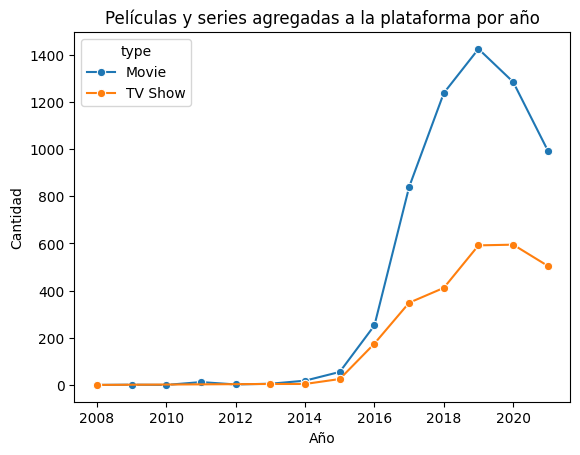

In [91]:
#Gráfico de líneas
sns.lineplot(
    data=agregados_tipo,
    x='year_added',
    y='count',
    hue='type',
    marker='o'
)

plt.title('Películas y series agregadas a la plataforma por año')
plt.xlabel('Año')
plt.ylabel('Cantidad')

## Géneros más populares

In [92]:
#Separando géneros
generos = df_netflix['listed_in'].str.split(',').explode().str.strip()
generos

0                  Documentaries
1         International TV Shows
1                      TV Dramas
1                   TV Mysteries
2                 Crime TV Shows
                  ...           
8805    Children & Family Movies
8805                    Comedies
8806                      Dramas
8806        International Movies
8806            Music & Musicals
Name: listed_in, Length: 19323, dtype: object

In [93]:
#conteo de géneros
conteo_generos = generos.value_counts().sort_values(ascending=False)
conteo_generos.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

[Text(1, 0, '2752'),
 Text(1, 0, '2427'),
 Text(1, 0, '1674'),
 Text(1, 0, '1351'),
 Text(1, 0, '869'),
 Text(1, 0, '859'),
 Text(1, 0, '763'),
 Text(1, 0, '756'),
 Text(1, 0, '641'),
 Text(1, 0, '616')]

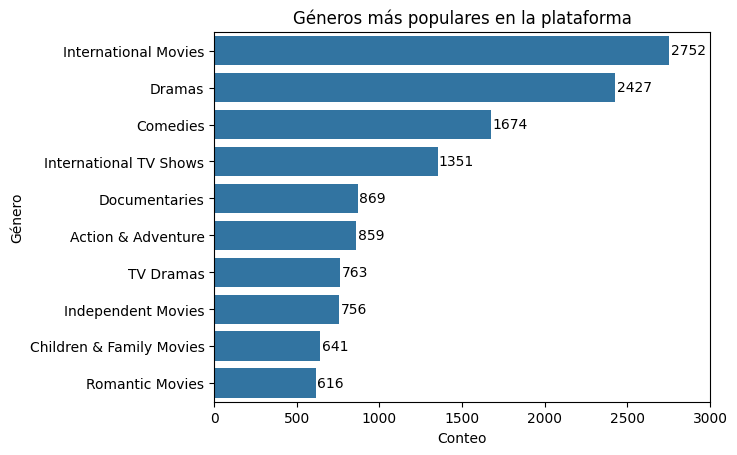

In [94]:
#Gráfico de géneros
graf_gen = sns.barplot(
    x = conteo_generos.head(10).values,
    y = conteo_generos.head(10).index
)

plt.title('Géneros más populares en la plataforma')
plt.xlabel('Conteo')
plt.ylabel('Género')
plt.xticks(range(0,3500,500))
graf_gen.bar_label(graf_gen.containers[0], padding = 1)

## Países con mayor cantidad de contenido en plataforma

In [95]:
#Identificando nulos
df_netflix['country'].isna().sum()

np.int64(831)

In [97]:
#Separando países
paises = df_netflix['country'].str.split(',').explode().str.strip()

#Conteo
conteo_paises = paises.value_counts()
conteo_paises

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 123, dtype: int64

[Text(1, 0, '3690'),
 Text(1, 0, '1046'),
 Text(1, 0, '806'),
 Text(1, 0, '445'),
 Text(1, 0, '393'),
 Text(1, 0, '318'),
 Text(1, 0, '232'),
 Text(1, 0, '231'),
 Text(1, 0, '226'),
 Text(1, 0, '169')]

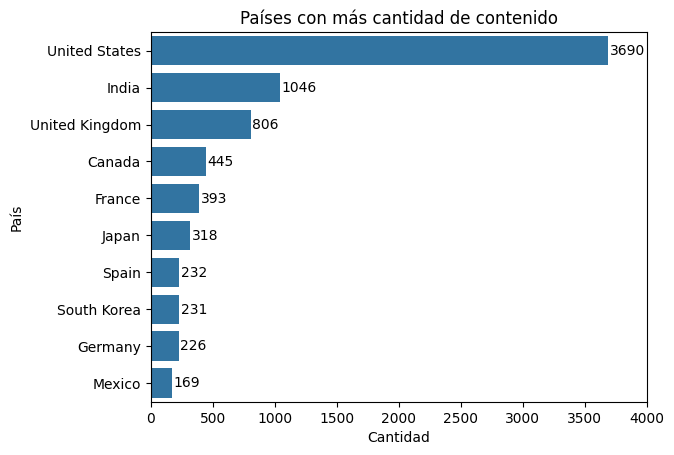

In [107]:
#Gráfica
graf_paises = sns.barplot(
    x = conteo_paises.head(10).values,
    y = conteo_paises.head(10).index
)

plt.title('Países con más cantidad de contenido')
plt.xlabel('Cantidad')
plt.ylabel('País')
plt.xticks(range(0,4500,500))
graf_paises.bar_label(graf_paises.containers[0], padding=1)

In [151]:
#Creando un DF para determinar los géneros que más aporta cada país
df_genero_pais = df_netflix.copy()

df_genero_pais['pais'] = (df_genero_pais['country'].str.split(','))
df_genero_pais['genero'] = (df_genero_pais['listed_in'].str.split(','))
df_genero_pais = (df_genero_pais.explode('pais').explode('genero'))

df_genero_pais['pais'] = df_genero_pais['pais'].str.strip()
df_genero_pais['genero'] = df_genero_pais['genero'].str.strip()

In [153]:
#Top 5 países con más producciones
top_paises = (df_genero_pais['pais'].value_counts().head().index)

#Top 5 géneros con más producciones
top_generos = (df_genero_pais['genero'].value_counts().head().index)

In [131]:
#Columnas a usar para el mapa de calor
heatmap_data = pd.crosstab(
    df_genero_pais['pais'],
    df_genero_pais['genero']
)

heatmap_data = heatmap_data.loc[
    top_paises,
    top_generos
]

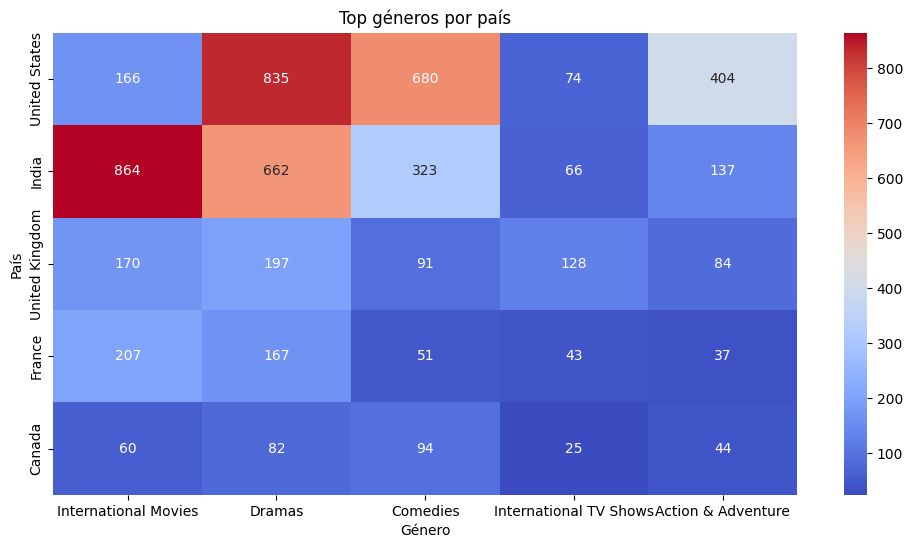

In [140]:
#Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title('Top géneros por país')
plt.xlabel('Género')
plt.ylabel('País')

plt.show()

## Directores con más producciones

In [142]:
#Separando directores
directores = df_netflix['director'].str.split(',').explode().str.strip()
directores

0       Kirsten Johnson
1                   NaN
2       Julien Leclercq
3                   NaN
4                   NaN
             ...       
8802      David Fincher
8803                NaN
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 9612, dtype: object

In [146]:
#Conteo de directores
conteo_dir = directores.value_counts(ascending=False)
conteo_dir

director
Rajiv Chilaka              22
Jan Suter                  21
Raúl Campos                19
Marcus Raboy               16
Suhas Kadav                16
                           ..
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Peter Hewitt                1
Jovanka Vuckovic            1
Name: count, Length: 4993, dtype: int64

[Text(1, 0, '22'),
 Text(1, 0, '21'),
 Text(1, 0, '19'),
 Text(1, 0, '16'),
 Text(1, 0, '16'),
 Text(1, 0, '15'),
 Text(1, 0, '13'),
 Text(1, 0, '12'),
 Text(1, 0, '12'),
 Text(1, 0, '12')]

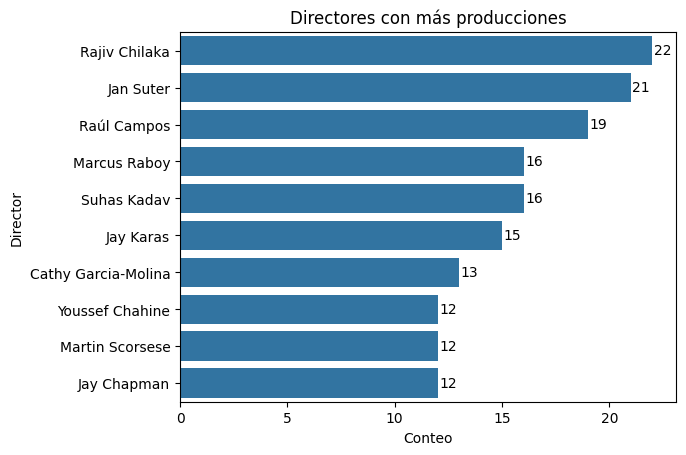

In [148]:
#Gráfico de barras
graf_dir = sns.barplot(
    x = conteo_dir.head(10).values,
    y = conteo_dir.head(10).index
)

plt.title('Directores con más producciones')
plt.xlabel('Conteo')
plt.ylabel('Director')
graf_dir.bar_label(graf_dir.containers[0], padding = 1)


In [164]:
#Creando un DF para determinar los géneros que más aporta cada director
df_genero_dir= df_netflix.copy()

df_genero_dir['director'] = (df_genero_dir['director'].str.split(','))
df_genero_dir['genero'] = (df_genero_dir['listed_in'].str.split(','))
df_genero_dir = (df_genero_dir.explode('director').explode('genero'))

df_genero_dir['director'] = df_genero_dir['director'].str.strip()
df_genero_dir['genero'] = df_genero_dir['genero'].str.strip()

In [169]:
#Top 5 directores con más producciones
top_dir = (df_genero_dir['director'].value_counts().head().index)

#Top 3 géneros con más producciones
top_generos = (df_genero_dir['genero'].value_counts().head(3).index)

In [170]:
#Columnas a usar para el mapa de calor
heatmap_data_dir = pd.crosstab(
    df_genero_dir['director'],
    df_genero_dir['genero']
)

heatmap_data_dir = heatmap_data_dir.loc[
    top_dir,
    top_generos
]

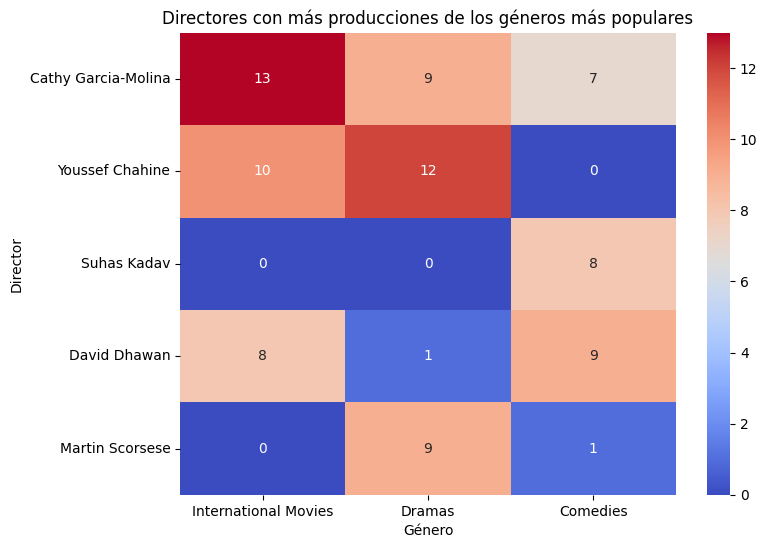

In [172]:
#Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data_dir,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title('Directores con más producciones de los géneros más populares')
plt.xlabel('Género')
plt.ylabel('Director')

plt.show()